In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from statsmodels.tsa.stattools import ccf
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11

In [7]:
import os

engine = create_engine(f"sqlite:///{os.path.expanduser('~/credit-cycle-analysis/data/fred_data.db')}")

df = pd.read_sql(text("SELECT * FROM macro_series ORDER BY date"),
                 con=engine.connect())

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df = df.resample("MS").mean()
df = df.ffill()
df = df.dropna()

print(f"Data loaded: {len(df)} rows")
df.head()

Data loaded: 426 rows


,fed_funds_rate,commercial_loans,consumer_credit,mortgage_rate_30yr,credit_card_delinquency,cpi
date,,,,,,
1991-01-01,6.91,636.1319,806600.50,9.6375,5.26,134.7
1991-02-01,6.25,635.9164,807030.43,9.3650,5.26,134.8
1991-03-01,6.12,635.2190,808351.83,9.5000,5.26,134.8
1991-04-01,5.91,631.3454,807818.95,9.4925,5.48,135.1
1991-05-01,5.78,627.7868,807832.16,9.4720,5.48,135.6


In [8]:
df_chg = df.pct_change(periods=1) * 100
df_chg = df_chg.dropna()

print("Monthly % changes (first 5 rows):")
df_chg.head()

Monthly % changes (first 5 rows):


,fed_funds_rate,commercial_loans,consumer_credit,mortgage_rate_30yr,credit_card_delinquency,cpi
date,,,,,,
1991-02-01,-9.551375,-0.033877,0.053301,-2.827497,0.00000,0.074239
1991-03-01,-2.080000,-0.109669,0.163736,1.441538,0.00000,0.000000
1991-04-01,-3.431373,-0.609805,-0.065922,-0.078947,4.18251,0.222552
1991-05-01,-2.199662,-0.563653,0.001635,-0.215960,0.00000,0.370096
1991-06-01,2.076125,-0.266906,-0.227461,1.509713,0.00000,0.294985


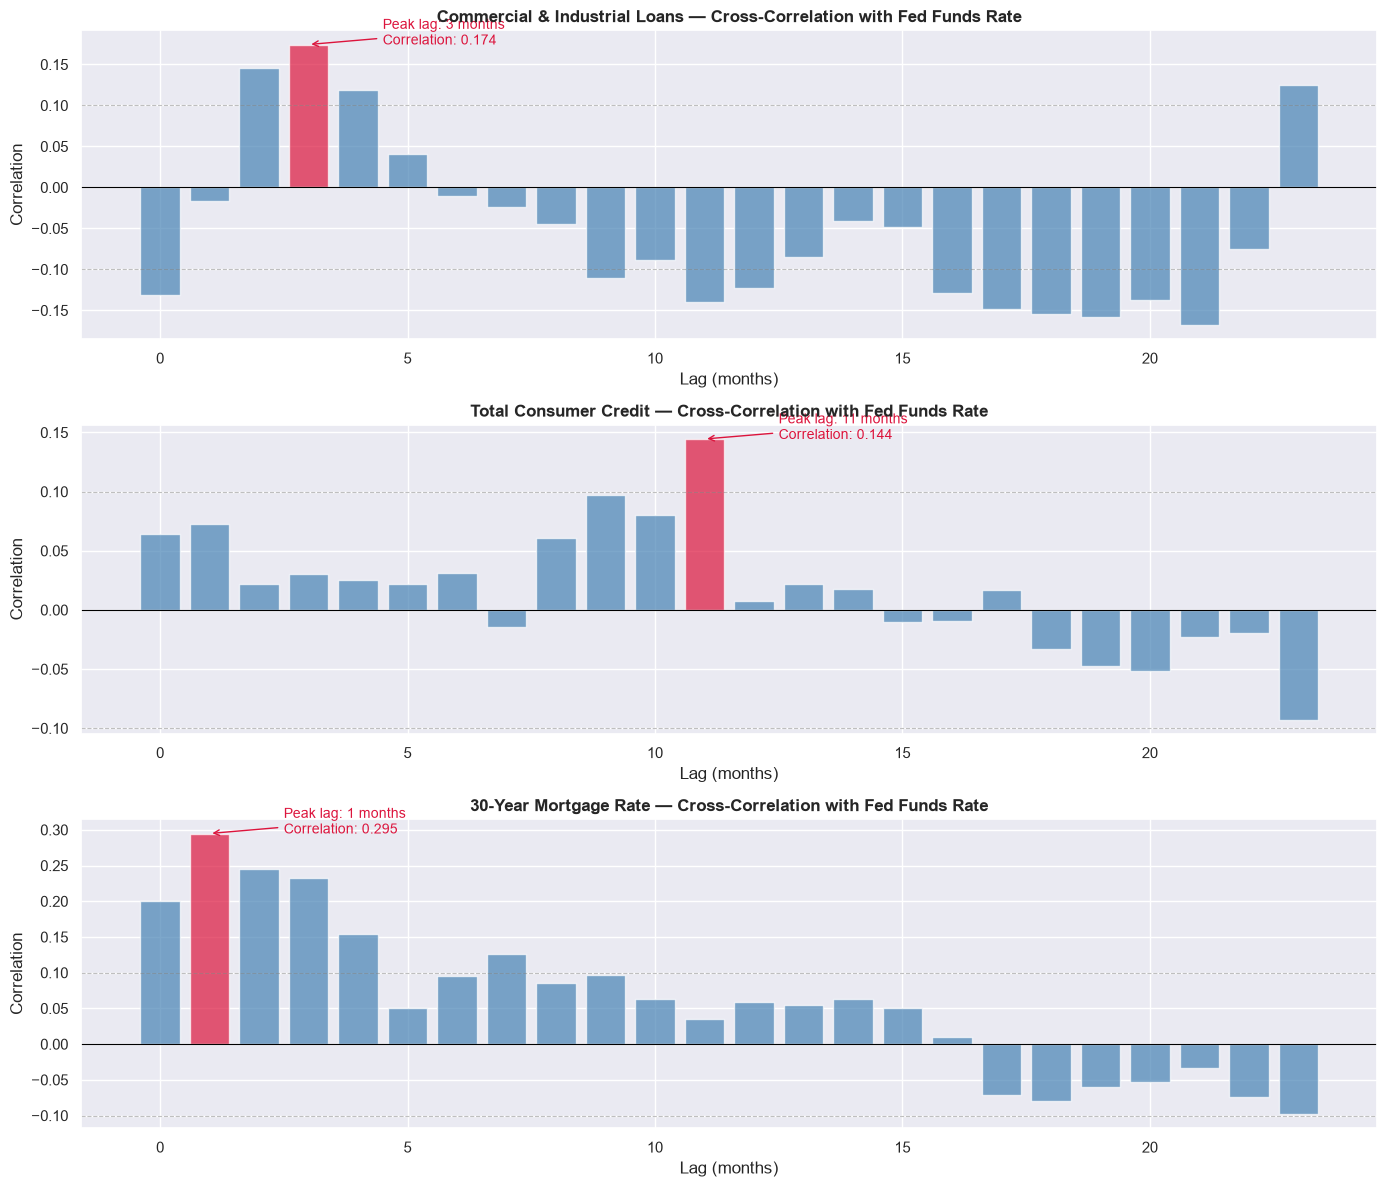


Summary of results:
  commercial_loans: peak lag = 3 months, correlation = 0.174
  consumer_credit: peak lag = 11 months, correlation = 0.144
  mortgage_rate_30yr: peak lag = 1 months, correlation = 0.295


In [10]:
credit_series = {
    "commercial_loans": "Commercial & Industrial Loans",
    "consumer_credit": "Total Consumer Credit",
    "mortgage_rate_30yr": "30-Year Mortgage Rate"
}

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

results = {}

for ax, (col, label) in zip(axes, credit_series.items()):
    correlation = ccf(df_chg["fed_funds_rate"], df_chg[col], nlags=24, unbiased=False)
    lags = range(len(correlation))  # Match lags exactly to correlation length
    
    abs_corr = np.abs(correlation)
    peak_lag = np.argmax(abs_corr)
    peak_corr = correlation[peak_lag]
    
    results[col] = {"peak_lag": peak_lag, "peak_correlation": round(peak_corr, 3)}
    
    ax.bar(lags, correlation, color=["crimson" if i == peak_lag else "steelblue" 
                                      for i in lags], alpha=0.7)
    ax.axhline(y=0, color="black", linewidth=0.8)
    ax.axhline(y=0.1, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axhline(y=-0.1, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_title(f"{label} — Cross-Correlation with Fed Funds Rate", fontweight="bold")
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("Correlation")
    ax.annotate(f"Peak lag: {peak_lag} months\nCorrelation: {peak_corr:.3f}",
                xy=(peak_lag, peak_corr),
                xytext=(peak_lag + 1.5, peak_corr),
                fontsize=10, color="crimson",
                arrowprops=dict(arrowstyle="->", color="crimson"))

plt.tight_layout()
plt.savefig(os.path.expanduser("~/credit-cycle-analysis/data/chart_lag_analysis.png"), 
            dpi=150, bbox_inches="tight")
plt.show()

print("\nSummary of results:")
for col, res in results.items():
    print(f"  {col}: peak lag = {res['peak_lag']} months, correlation = {res['peak_correlation']}")